In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
#TODO: MEedSAM

### All results are calculated on 11 testing subjects

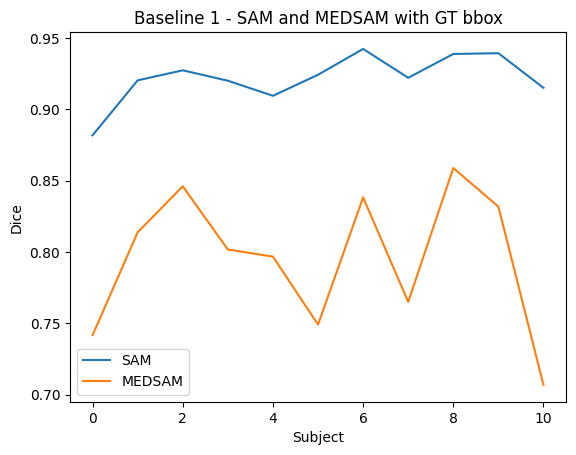

In [3]:
# baseline 1 - SAM gt bbox
sam_gt_noseed = np.load('./results/dice/original/sam_vit_b_roi_testing_3views_seedFalse.npy')
medsam_gt_noseed = np.load('./results/dice/original/medsam_vit_b_roi_testing_3views_seedFalse.npy')
plt.plot(sam_gt_noseed, label='SAM')
plt.plot(medsam_gt_noseed, label='MEDSAM')
plt.title('Baseline 1 - SAM and MEDSAM with GT bbox')
plt.xlabel('Subject')
plt.ylabel('Dice')
plt.legend()
plt.show()

In [14]:
# baseline 1 - SAM gt 20 pixels jitter bbox
sam_dice_3views = []
sam_dice_axial = []
sam_dice_coronal = []
sam_dice_sagittal = []
for s in range(2020, 2025):
    sam_dice_3views.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_3views_seed{s}.npy'))
    sam_dice_axial.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_axial_seed{s}.npy'))
    sam_dice_coronal.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_coronal_seed{s}.npy'))
    sam_dice_sagittal.append(np.load(f'./results/dice/original/sam_vit_b_roi_testing_sagittal_seed{s}.npy'))

sam_dice_3views = np.array(sam_dice_3views)
sam_dice_axial = np.array(sam_dice_axial)
sam_dice_coronal = np.array(sam_dice_coronal)
sam_dice_sagittal = np.array(sam_dice_sagittal)       
print(sam_dice_3views.shape, sam_dice_axial.shape, sam_dice_coronal.shape, sam_dice_sagittal.shape)

sam_dice_3views_mean = np.mean(sam_dice_3views, axis=0)
sam_dice_3views_std = np.std(sam_dice_3views, axis=0)
sam_dice_axial_mean = np.mean(sam_dice_axial, axis=0)
sam_dice_axial_std = np.std(sam_dice_axial, axis=0)
sam_dice_coronal_mean = np.mean(sam_dice_coronal, axis=0)
sam_dice_coronal_std = np.std(sam_dice_coronal, axis=0)
sam_dice_sagittal_mean = np.mean(sam_dice_sagittal, axis=0)
sam_dice_sagittal_std = np.std(sam_dice_sagittal, axis=0)
print(sam_dice_3views_mean.shape, sam_dice_axial_mean.shape, sam_dice_coronal_mean.shape, sam_dice_sagittal_mean.shape)

(5, 11) (5, 11) (5, 11) (5, 11)
(11,) (11,) (11,) (11,)


In [16]:
# baseline 2 = DynUNet using all 40 subjects
dynunet_dice_40 = []
for s in range(2020, 2025):
    dynunet_dice_40.append(np.load(f'./results/dice//epochs100/random_MRI_LeftKidney_DynUNet_epochs100_seed{s}_test_40samples_dice.npy'))
dynunet_dice_40 = np.array(dynunet_dice_40)
print(dynunet_dice_40.shape)
dynunet_dice_40_mean = np.mean(dynunet_dice_40, axis=0)
dynunet_dice_40_std = np.std(dynunet_dice_40, axis=0)
print(dynunet_dice_40_mean.shape)

(5, 11)
(11,)


In [27]:
def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


(0.25, 5.75)

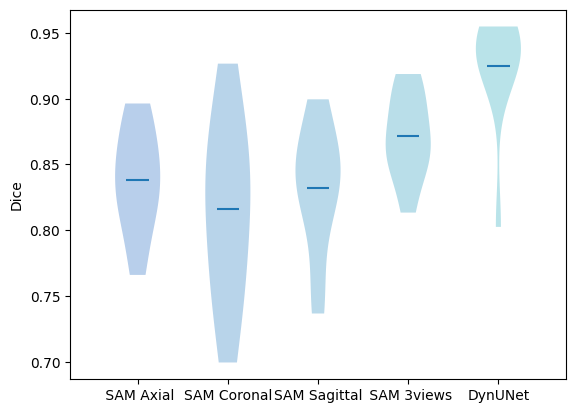

In [39]:
# volin plot of dice on sam and dynunet
x_labels = [ ' SAM Axial', 'SAM Coronal', 'SAM Sagittal', ' SAM 3views', 'DynUNet']
data = [sam_dice_axial_mean, sam_dice_coronal_mean, sam_dice_sagittal_mean, sam_dice_3views_mean, dynunet_dice_40_mean]
data_std = [sam_dice_axial_std, sam_dice_coronal_std, sam_dice_sagittal_std, sam_dice_3views_std, dynunet_dice_40_std]
c1 = '#1560bd'
c2 = '#1aa4b8'
colors = get_color_gradient(c1, c2, len(x_labels))
fig, ax = plt.subplots(1,1)
plots = ax.violinplot(data, showmeans=True, showmedians=False, showextrema=False)
# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)

# Set the color of the median lines
# for median, color in zip(plots['cmedians'].get_paths(), colors):
#     median.set_color(color)

ax.set_ylabel('Dice')
ax.set_xticks(np.arange(1, len(x_labels) + 1), labels=x_labels)
ax.set_xlim(0.25, len(x_labels) + 0.75)

# TODO: add individual points, y scale

In [35]:
bbox_regression_axial_dice = []
bbox_regression_coronal_dice = []
bbox_regression_sagittal_dice = []
bbox_regression_3views_dice = []
dynunet_dice = []

for seed in range(2020,2023):
    seed_bbox_regression_axial_dice = []
    seed_bbox_regression_coronal_dice = []
    seed_bbox_regression_sagittal_dice = []
    seed_bbox_regression_3views_dice = []
    seed_dynunet_dice = []
    for i in range(1,41):
        seed_bbox_regression_axial_dice.append(np.load(f'./results/dice/bbox_regression/test_vote_upsampled_axial_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_coronal_dice.append(np.load(f'./results/dice/bbox_regression/test_vote_upsampled_coronal_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_sagittal_dice.append(np.load(f'./results/dice/bbox_regression/test_vote_upsampled_sagittal_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_bbox_regression_3views_dice.append(np.load(f'./results/dice/bbox_regression/test_vote_upsampled_3views_emb_bseed2023_sample{i}_sseed{seed}.npy'))
        seed_dynunet_dice.append(np.load(f'./results/dice/epochs100/random_MRI_LeftKidney_DynUNet_epochs100_seed{seed}_test_{i}samples_dice.npy'))

    bbox_regression_axial_dice.append(seed_bbox_regression_axial_dice)
    bbox_regression_coronal_dice.append(seed_bbox_regression_coronal_dice)
    bbox_regression_sagittal_dice.append(seed_bbox_regression_sagittal_dice)
    bbox_regression_3views_dice.append(seed_bbox_regression_3views_dice)
    dynunet_dice.append(seed_dynunet_dice)

bbox_regression_axial_dice = np.array(bbox_regression_axial_dice)
bbox_regression_coronal_dice = np.array(bbox_regression_coronal_dice)
bbox_regression_sagittal_dice = np.array(bbox_regression_sagittal_dice)
bbox_regression_3views_dice = np.array(bbox_regression_3views_dice)
dynunet_dice = np.array(dynunet_dice)

bbox_regression_axial_dice_mean = np.mean(bbox_regression_axial_dice, axis=0)
bbox_regression_coronal_dice_mean = np.mean(bbox_regression_coronal_dice, axis=0)
bbox_regression_sagittal_dice_mean = np.mean(bbox_regression_sagittal_dice, axis=0)
bbox_regression_3views_dice_mean = np.mean(bbox_regression_3views_dice, axis=0)
dynunet_dice_mean = np.mean(dynunet_dice, axis=0)

In [10]:
bbox_regression_3views_dice.shape, bbox_regression_3views_dice_mean.shape

((3, 40, 11), (40, 11))

In [36]:
avg_bbox_regression_3views_dice_mean = np.mean(bbox_regression_3views_dice_mean, axis=-1)
avg_bbox_regression_3views_dice_std = np.std(bbox_regression_3views_dice_mean, axis=-1)
avg_bbox_regression_axial_dice_mean = np.mean(bbox_regression_axial_dice_mean, axis=-1)
avg_bbox_regression_axial_dice_std = np.std(bbox_regression_axial_dice_mean, axis=-1)
avg_bbox_regression_coronal_dice_mean = np.mean(bbox_regression_coronal_dice_mean, axis=-1)
avg_bbox_regression_coronal_dice_std = np.std(bbox_regression_coronal_dice_mean, axis=-1)
avg_bbox_regression_sagittal_dice_mean = np.mean(bbox_regression_sagittal_dice_mean, axis=-1)
avg_bbox_regression_sagittal_dice_std = np.std(bbox_regression_sagittal_dice_mean, axis=-1)
avg_dynunet_dice_mean = np.mean(dynunet_dice_mean, axis=-1)
avg_dynunet_dice_std = np.std(dynunet_dice_mean, axis=-1)


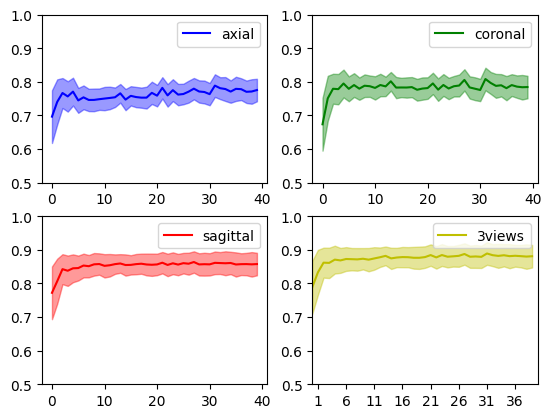

In [33]:
fig, ax = plt.subplots(2,2)
ax[0,0].plot(avg_bbox_regression_axial_dice_mean, label='axial', color='b')
ax[0,0].fill_between(range(len(avg_bbox_regression_axial_dice_mean)), avg_bbox_regression_axial_dice_mean-avg_bbox_regression_3views_dice_std, avg_bbox_regression_axial_dice_mean+avg_bbox_regression_3views_dice_std, alpha=0.4, color='b')
ax[0,0].legend()
ax[0,0].set_ylim(0.5, 1)
# ax[0,0].set_title('SAM Axial')

ax[0,1].plot(avg_bbox_regression_coronal_dice_mean, label='coronal', color='g')
ax[0,1].fill_between(range(len(avg_bbox_regression_coronal_dice_mean)), avg_bbox_regression_coronal_dice_mean-avg_bbox_regression_3views_dice_std, avg_bbox_regression_coronal_dice_mean+avg_bbox_regression_3views_dice_std, alpha=0.4, color='g')
ax[0,1].legend()
ax[0,1].set_ylim(0.5, 1)

ax[1,0].plot(avg_bbox_regression_sagittal_dice_mean, label='sagittal', color='r')
ax[1,0].fill_between(range(len(avg_bbox_regression_sagittal_dice_mean)), avg_bbox_regression_sagittal_dice_mean-avg_bbox_regression_3views_dice_std, avg_bbox_regression_sagittal_dice_mean+avg_bbox_regression_3views_dice_std, alpha=0.4, color='r')
ax[1,0].legend()
ax[1,0].set_ylim(0.5, 1)

ax[1,1].plot(avg_bbox_regression_3views_dice_mean, label='3views', color='y')
ax[1,1].fill_between(range(len(avg_bbox_regression_3views_dice_mean)), avg_bbox_regression_3views_dice_mean-avg_bbox_regression_3views_dice_std, avg_bbox_regression_3views_dice_mean+avg_bbox_regression_3views_dice_std, alpha=0.4, color='y')
ax[1,1].legend()
ax[1,1].set_ylim(0.5, 1)
ax[1,1].set_xlim(0,40)
ax[1,1].set_xticks(range(1,41,5))

plt.legend()
plt.show()

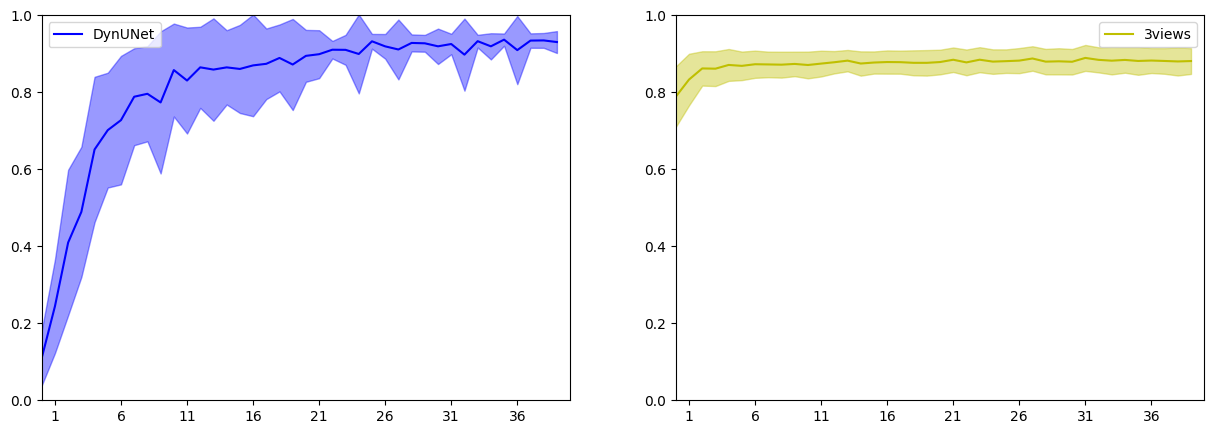

In [40]:
fig,ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(avg_dynunet_dice_mean, label='DynUNet', color='b')
ax[0].fill_between(range(len(avg_dynunet_dice_mean)), avg_dynunet_dice_mean-avg_dynunet_dice_std, avg_dynunet_dice_mean+avg_dynunet_dice_std, alpha=0.4, color='b')
ax[0].legend()
ax[0].set_ylim(0, 1)
ax[0].set_xlim(0,40)
ax[0].set_xticks(range(1,41,5))


ax[1].plot(avg_bbox_regression_3views_dice_mean, label='3views', color='y')
ax[1].fill_between(range(len(avg_bbox_regression_3views_dice_mean)), avg_bbox_regression_3views_dice_mean-avg_bbox_regression_3views_dice_std, avg_bbox_regression_3views_dice_mean+avg_bbox_regression_3views_dice_std, alpha=0.4, color='y')
ax[1].legend()
ax[1].set_ylim(0, 1)
ax[1].set_xlim(0,40)
ax[1].set_xticks(range(1,41,5))
plt.legend()
plt.show()